# Week 2: Context, Sampling and In-Context Learning

**Task:** Systematically vary few-shot examples (count, order, format) on a fixed task and document what actually moves output quality.

**Reading:** *Language Models are Few-Shot Learners* (Brown et al., 2020), the GPT-3 paper.

**Setup**

| | |
|---|---|
| Model | **Qwen2.5-0.5B (base)**. GPT-3 studied ICL on *base* models; instruction-tuned models blur the effect |
| Task | **SST-2** binary movie-review sentiment, 150 fixed test reviews (dev split) |
| Demo pool | SST-2 train, 5–40 words |
| Scoring | Compare log-probs of the two label tokens (as in GPT-3's classification evals). No sampling noise |

**Experiments**

| # | Factor varied | Held fixed |
|---|---|---|
| E1 | **Count**: k = 0, 1, 2, 4, 8, 16 (5 random demo sets each) | format |
| E2 | **Order**: all 24 orderings of 4 demos (2 demo sets) | demos, format |
| E3 | **Format**: 5 templates + 4 label-word choices, at k = 0 and k = 4 | demos |
| E4 | **Label correctness**: gold vs random vs flipped labels (k = 8) | demos, format |
| E5 | **Label balance**: 0–4 positives out of 4 demos | format |

Then: sampling (temperature/top-p/top-k) applied to ICL, and context-window limits.

In [1]:
import sys, json, math, random, time, re, itertools, warnings
from pathlib import Path
import numpy as np, torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, logging as hf_logging

warnings.filterwarnings("ignore"); hf_logging.set_verbosity_error()
ROOT = Path.cwd().parent if Path.cwd().name == "jupyter" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from icl import Example, Format, load_sst2, sample_demos, evaluate, summarise, score, label_token_ids

RESULTS = ROOT / "results" / "week2"; RESULTS.mkdir(parents=True, exist_ok=True)
MODEL = "Qwen/Qwen2.5-0.5B"
tok = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=torch.float32).eval()

train, dev = load_sst2("train"), load_sst2("dev")
POOL = [e for e in train if 5 <= len(e.text.split()) <= 40]
TEST = random.Random(0).sample(dev, 150)
GOLD = np.array([e.label for e in TEST])
print(f"model={MODEL}  pool={len(POOL)}  test={len(TEST)} ({GOLD.mean():.0%} positive, so the majority baseline is {max(GOLD.mean(), 1-GOLD.mean()):.0%})")

model=Qwen/Qwen2.5-0.5B  pool=6560  test=150 (56% positive, so the majority baseline is 56%)


## How a few-shot prompt looks

The demos are concatenated, then the query is appended **without** a trailing space (Week 1 lesson: the space belongs to the label token `' positive'`). **Exception:** Qwen splits digits individually, so `' 0'` is two tokens (`' '` + `'0'`). For the `0/1` format the space has to stay in the prompt, the opposite of the GPT-2 rule. Always check how *your* model tokenises its labels. The model "answers" by putting more probability on `' positive'` or on `' negative'`.

In [2]:
FORMATS = {
    "review":        Format("review",        "Review: {x}\nSentiment: {y}"),
    "input/output":  Format("input/output",  "Input: {x}\nOutput: {y}"),
    "minimal":       Format("minimal",       "{x}\n{y}"),
    "question":      Format("question",      "Text: {x}\nQuestion: Is the sentiment of this text positive or negative?\nAnswer: {y}"),
    "review+instr":  Format("review+instr",  "Review: {x}\nSentiment: {y}",
                            instruction="Classify the sentiment of each movie review as positive or negative."),
    "great/terrible": Format("great/terrible", "Review: {x}\nSentiment: {y}", labels=("terrible", "great")),
    "good/bad":       Format("good/bad",       "Review: {x}\nSentiment: {y}", labels=("bad", "good")),
    "0/1":            Format("0/1",            "Review: {x}\nSentiment: {y}", labels=("0", "1"), space_in_query=True),  # Qwen: " 0" = " " + "0"
    "foo/bar":        Format("foo/bar",        "Review: {x}\nSentiment: {y}", labels=("foo", "bar")),   # arbitrary symbols
}
BASE = FORMATS["review"]
demo = sample_demos(POOL, 2, seed=0)
print(BASE.prefix(demo) + BASE.query(TEST[0].text) + "   <- model scores", BASE.label_strings())
for f in FORMATS.values():
    label_token_ids(tok, f)          # asserts each label pair has distinct first tokens

Review: undoubtedly the scariest movie ever made about tattoos .
Sentiment: positive

Review: director yu seems far more interested in gross-out humor than in showing us well-thought stunts or a car chase that we have n't seen 10,000 times .
Sentiment: negative

Review: it 's dumb , but more importantly , it 's just not scary .
Sentiment:   <- model scores (' negative', ' positive')


### Sanity check: the KV-cache shortcut is exact

All queries in a configuration share one prefix. `src/icl.py` encodes that prefix once and reuses its key/value cache for every query (the same KV cache as in Week 1, used here for speed). First we confirm it gives the same numbers as scoring each full prompt from scratch.

In [3]:
demos = sample_demos(POOL, 8, seed=0)
ids = label_token_ids(tok, BASE)
fast, _ = score(model, tok, BASE.prefix(demos), [BASE.query(e.text) for e in TEST[:5]], ids)
with torch.no_grad():
    slow = torch.stack([torch.log_softmax(model(tok(BASE.prefix(demos) + BASE.query(e.text), return_tensors="pt").input_ids).logits[0, -1], -1)[ids]
                        for e in TEST[:5]])
print("max |cached - full| =", (fast - slow).abs().max().item())

max |cached - full| = 1.1205673217773438e-05


## Run all experiments

Results are cached to `results/week2/icl_runs.jsonl`, so re-running the notebook only computes what's missing. A full run takes about 1.5 hours on an Intel laptop CPU.

Each run records accuracy, accuracy after **contextual calibration** (Zhao et al., 2021: divide out the model's bias on the content-free input "N/A"), the positive-prediction rate, and **label mass**, i.e. how much of the full-vocabulary probability lands on a valid label at all.

In [4]:
RUNS = RESULTS / "icl_runs.jsonl"
done = {json.loads(l)["id"] for l in RUNS.open()} if RUNS.exists() else set()

def run(id, fmt, demos, labels=None, **meta):
    if id in done:
        return
    t = time.time()
    r = summarise(evaluate(model, tok, fmt, demos, TEST, demo_labels=labels), TEST)
    r.update(id=id, fmt=fmt.name, k=len(demos), demo_labels=labels or [d.label for d in demos], **meta)
    with RUNS.open("a") as f:
        f.write(json.dumps(r) + "\n")
    done.add(id)
    print(f"{id:40} acc={r['acc']:.3f} cal={r['acc_cal']:.3f} mass={r['label_mass']:.2f} ({time.time()-t:.0f}s)", flush=True)

# E1 count
for k in [0, 1, 2, 4, 8, 16]:
    for seed in ([0] if k == 0 else range(5)):
        run(f"count|k{k}|s{seed}", BASE, sample_demos(POOL, k, seed), exp="count", seed=seed)
# E2 order: every permutation of two fixed 4-demo sets
for set_seed in [100, 101]:
    base = sample_demos(POOL, 4, set_seed)
    for p, perm in enumerate(itertools.permutations(range(4))):
        run(f"order|set{set_seed}|p{p}", BASE, [base[i] for i in perm], exp="order", set=set_seed, perm=list(perm))
# E3 format (zero-shot and 4-shot)
for name, f in FORMATS.items():
    run(f"format|{name}|k0", f, [], exp="format", seed=0)
    for seed in range(3):
        run(f"format|{name}|k4|s{seed}", f, sample_demos(POOL, 4, seed), exp="format", seed=seed)
# E4 label correctness (k = 8)
for seed in range(5):
    d = sample_demos(POOL, 8, seed); rng = random.Random(1000 + seed)
    run(f"labels|gold|s{seed}",    BASE, d, None,                                  exp="labels", variant="gold", seed=seed)
    run(f"labels|random|s{seed}",  BASE, d, [rng.randint(0, 1) for _ in d],        exp="labels", variant="random", seed=seed)
    run(f"labels|flipped|s{seed}", BASE, d, [1 - x.label for x in d],              exp="labels", variant="flipped", seed=seed)
# E5 label balance (k = 4)
for n_pos in range(5):
    for seed in range(3):
        run(f"balance|pos{n_pos}|s{seed}", BASE, sample_demos(POOL, 4, seed, n_pos=n_pos), exp="balance", n_pos=n_pos, seed=seed)

R = [json.loads(l) for l in RUNS.open()]
print(len(R), "runs loaded")

140 runs loaded


In [5]:
def sel(exp, **kw):
    return [r for r in R if r["exp"] == exp and all(r.get(k) == v for k, v in kw.items())]
def ms(rs, key="acc"):
    v = np.array([r[key] for r in rs]); return v.mean(), v.std(), v.min(), v.max()

## E1: Number of examples (k)

  k acc mean   std   min   max  calib label mass prefix tok
  0    0.873 0.000 0.873 0.873  0.780       0.62          0
  1    0.739 0.104 0.593 0.907  0.873       0.87         28
  2    0.872 0.034 0.807 0.900  0.856       0.90         54
  4    0.855 0.025 0.813 0.880  0.888       0.95        106
  8    0.896 0.016 0.873 0.913  0.867       0.98        243
 16    0.900 0.009 0.887 0.913  0.856       0.99        484


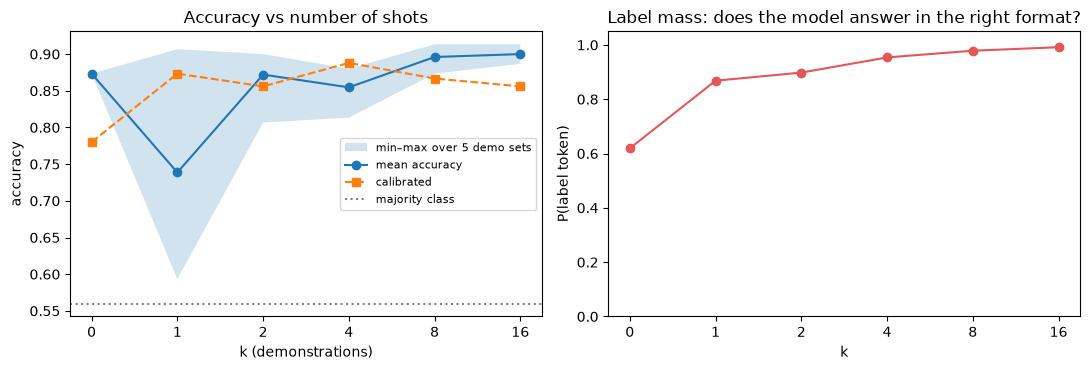

In [6]:
ks = [0, 1, 2, 4, 8, 16]
rows = []
for k in ks:
    rs = sel("count", k=k)
    rows.append((k, *ms(rs), ms(rs, "acc_cal")[0], ms(rs, "label_mass")[0], np.mean([r["prefix_tokens"] for r in rs])))
print(f"{'k':>3} {'acc mean':>8} {'std':>5} {'min':>5} {'max':>5} {'calib':>6} {'label mass':>10} {'prefix tok':>10}")
for k, m, s, lo, hi, cal, mass, pt in rows:
    print(f"{k:>3} {m:8.3f} {s:5.3f} {lo:5.3f} {hi:5.3f} {cal:6.3f} {mass:10.2f} {pt:10.0f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
m = np.array([r[1] for r in rows]); s = np.array([r[2] for r in rows])
ax[0].fill_between(range(len(ks)), [r[3] for r in rows], [r[4] for r in rows], alpha=.2, label="min–max over 5 demo sets")
ax[0].plot(range(len(ks)), m, "o-", label="mean accuracy"); ax[0].plot(range(len(ks)), [r[5] for r in rows], "s--", label="calibrated")
ax[0].axhline(max(GOLD.mean(), 1 - GOLD.mean()), color="grey", ls=":", label="majority class")
ax[0].set_xticks(range(len(ks))); ax[0].set_xticklabels(ks); ax[0].set_xlabel("k (demonstrations)"); ax[0].set_ylabel("accuracy")
ax[0].set_title("Accuracy vs number of shots"); ax[0].legend(fontsize=8)
ax[1].plot(range(len(ks)), [r[6] for r in rows], "o-", color="#E45756")
ax[1].set_xticks(range(len(ks))); ax[1].set_xticklabels(ks); ax[1].set_ylim(0, 1.05)
ax[1].set_xlabel("k"); ax[1].set_ylabel("P(label token)"); ax[1].set_title("Label mass: does the model answer in the right format?")
plt.tight_layout(); plt.savefig(RESULTS / "e1_count.png", dpi=130); plt.show()

## E2: Order of examples

Same 4 demos, all 24 orderings. If ICL were "reading the examples like a human", order wouldn't matter.

set 100: acc 0.876 ± 0.024  range 0.820–0.900  | calibrated 0.858 ± 0.019  range 0.793–0.887
          predicted-positive rate when LAST demo is positive: 0.57, negative: 0.47
set 101: acc 0.864 ± 0.031  range 0.813–0.907  | calibrated 0.870 ± 0.017  range 0.840–0.907
          predicted-positive rate when LAST demo is positive: 0.56, negative: 0.45


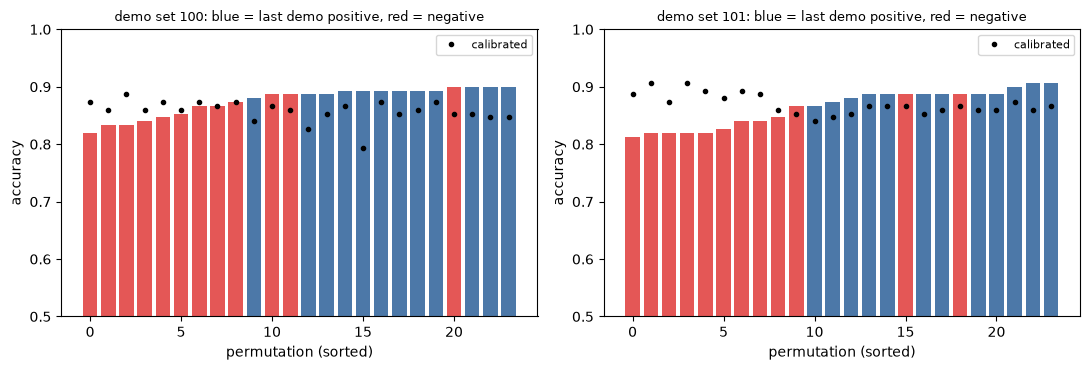

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for j, set_seed in enumerate([100, 101]):
    rs = sel("order", set=set_seed)
    acc = np.array([r["acc"] for r in rs]); cal = np.array([r["acc_cal"] for r in rs])
    last = np.array([r["demo_labels"][-1] for r in rs]); pos = np.array([r["pos_rate"] for r in rs])
    print(f"set {set_seed}: acc {acc.mean():.3f} ± {acc.std():.3f}  range {acc.min():.3f}–{acc.max():.3f}  "
          f"| calibrated {cal.mean():.3f} ± {cal.std():.3f}  range {cal.min():.3f}–{cal.max():.3f}")
    print(f"          predicted-positive rate when LAST demo is positive: {pos[last==1].mean():.2f}, negative: {pos[last==0].mean():.2f}")
    order = np.argsort(acc)
    ax[j].bar(range(24), acc[order], color=["#4C78A8" if l else "#E45756" for l in last[order]])
    ax[j].plot(range(24), cal[order], "k.", label="calibrated")
    ax[j].set_ylim(.5, 1); ax[j].set_xlabel("permutation (sorted)"); ax[j].set_ylabel("accuracy")
    ax[j].set_title(f"demo set {set_seed}: blue = last demo positive, red = negative", fontsize=9); ax[j].legend(fontsize=8)
plt.tight_layout(); plt.savefig(RESULTS / "e2_order.png", dpi=130); plt.show()

In [8]:
rs = sel("order", set=100)
best, worst = max(rs, key=lambda r: r["acc"]), min(rs, key=lambda r: r["acc"])
fmt_labels = lambda r: " ".join("+" if l else "-" for l in r["demo_labels"])
print(f"best  order {best['perm']}  labels [{fmt_labels(best)}]  acc {best['acc']:.3f}  pos_rate {best['pos_rate']:.2f}")
print(f"worst order {worst['perm']}  labels [{fmt_labels(worst)}]  acc {worst['acc']:.3f}  pos_rate {worst['pos_rate']:.2f}")

best  order [0, 3, 2, 1]  labels [+ - - +]  acc 0.900  pos_rate 0.55
worst order [3, 0, 1, 2]  labels [- + + -]  acc 0.820  pos_rate 0.42


## E3: Format (template and label words)

format          0-shot  mass | 4-shot     ±
review           0.873  0.62 |  0.851 0.028
input/output     0.747  0.00 |  0.709 0.143
minimal          0.460  0.00 |  0.773 0.120
question         0.593  0.05 |  0.487 0.024
review+instr     0.813  0.15 |  0.816 0.025
great/terrible   0.733  0.00 |  0.891 0.013
good/bad         0.720  0.00 |  0.887 0.011
0/1              0.560  0.43 |  0.582 0.102
foo/bar          0.560  0.00 |  0.716 0.125


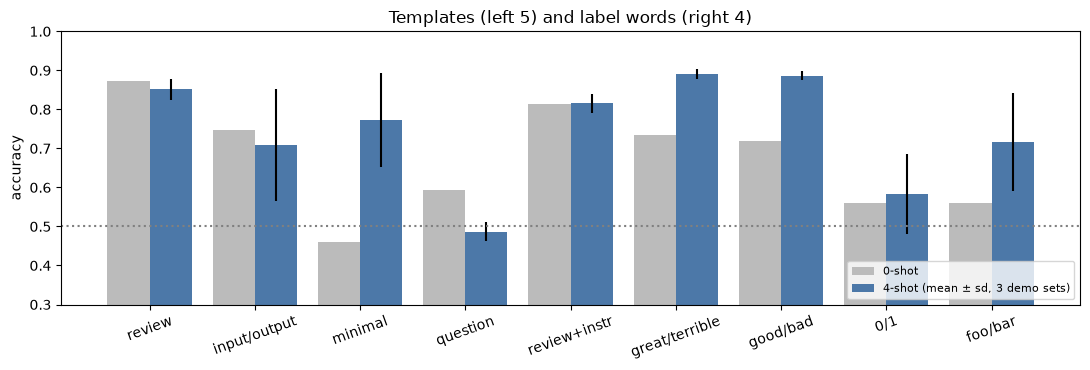

In [9]:
names = list(FORMATS)
z = [sel("format", fmt=n, k=0)[0]["acc"] for n in names]
f4 = [ms(sel("format", fmt=n, k=4)) for n in names]
zm = [sel("format", fmt=n, k=0)[0]["label_mass"] for n in names]
print(f"{'format':15} {'0-shot':>6} {'mass':>5} | {'4-shot':>6} {'±':>5}")
for n, a, mm, (m, s, *_ ) in zip(names, z, zm, f4):
    print(f"{n:15} {a:6.3f} {mm:5.2f} | {m:6.3f} {s:5.3f}")
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(x - .2, z, .4, label="0-shot", color="#BBBBBB")
ax.bar(x + .2, [f[0] for f in f4], .4, yerr=[f[1] for f in f4], label="4-shot (mean ± sd, 3 demo sets)", color="#4C78A8")
ax.axhline(.5, color="grey", ls=":"); ax.set_ylim(.3, 1)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20); ax.set_ylabel("accuracy"); ax.legend(loc="lower right", fontsize=8)
ax.set_title("Templates (left 5) and label words (right 4)")
plt.tight_layout(); plt.savefig(RESULTS / "e3_format.png", dpi=130); plt.show()

## E4: Do the labels in the demos even need to be correct?

Min et al. (2022) found that **randomly** labelled demos hurt surprisingly little: demos mostly teach the *format* and *label space*. Wei et al. (2023) found that only **large** models follow **flipped** labels; small models stick to their prior.

In [10]:
for v in ["gold", "random", "flipped"]:
    m, s, lo, hi = ms(sel("labels", variant=v))
    print(f"{v:8} acc {m:.3f} ± {s:.3f}   (range {lo:.3f}–{hi:.3f})")
zero = sel("count", k=0)[0]["acc"]
print(f"0-shot   acc {zero:.3f}")

gold     acc 0.896 ± 0.016   (range 0.873–0.913)
random   acc 0.884 ± 0.029   (range 0.827–0.907)
flipped  acc 0.836 ± 0.031   (range 0.800–0.893)
0-shot   acc 0.873


## E5: Label balance (majority-label bias)

0/4 positive demos: acc 0.762  calibrated 0.893  predicted-positive rate 0.33
1/4 positive demos: acc 0.820  calibrated 0.887  predicted-positive rate 0.41
2/4 positive demos: acc 0.851  calibrated 0.880  predicted-positive rate 0.47
3/4 positive demos: acc 0.882  calibrated 0.847  predicted-positive rate 0.57
4/4 positive demos: acc 0.847  calibrated 0.811  predicted-positive rate 0.67


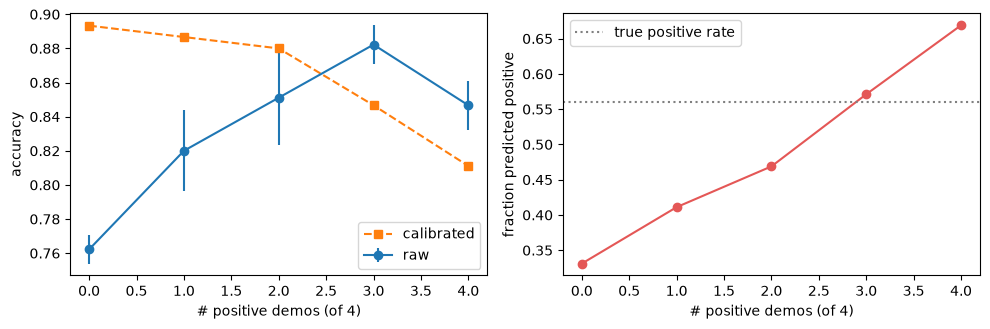

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
npos = range(5)
acc = [ms(sel("balance", n_pos=n)) for n in npos]; pr = [ms(sel("balance", n_pos=n), "pos_rate") for n in npos]
cal = [ms(sel("balance", n_pos=n), "acc_cal") for n in npos]
for n, a, p, c in zip(npos, acc, pr, cal):
    print(f"{n}/4 positive demos: acc {a[0]:.3f}  calibrated {c[0]:.3f}  predicted-positive rate {p[0]:.2f}")
ax[0].errorbar(npos, [a[0] for a in acc], [a[1] for a in acc], marker="o", label="raw")
ax[0].plot(npos, [c[0] for c in cal], "s--", label="calibrated"); ax[0].legend()
ax[0].set_xlabel("# positive demos (of 4)"); ax[0].set_ylabel("accuracy")
ax[1].plot(npos, [p[0] for p in pr], "o-", color="#E45756"); ax[1].axhline(GOLD.mean(), color="grey", ls=":", label="true positive rate")
ax[1].set_xlabel("# positive demos (of 4)"); ax[1].set_ylabel("fraction predicted positive"); ax[1].legend()
plt.tight_layout(); plt.savefig(RESULTS / "e5_balance.png", dpi=130); plt.show()

## Summary: what actually moves accuracy?

For each factor: the spread (max − min) of accuracy you get by changing **only** that factor. This is the headline chart.

template (0-shot)             41.3 accuracy points
template (4-shot)             36.4 accuracy points
label words (4-shot)          30.9 accuracy points
k (0→16), mean over sets      16.1 accuracy points
label balance (k=4)           12.0 accuracy points
order (24 perms, set 101)      9.3 accuracy points
order (24 perms, set 100)      8.0 accuracy points
which demos (k=4, 5 sets)      6.7 accuracy points
label correctness (k=8)        6.0 accuracy points


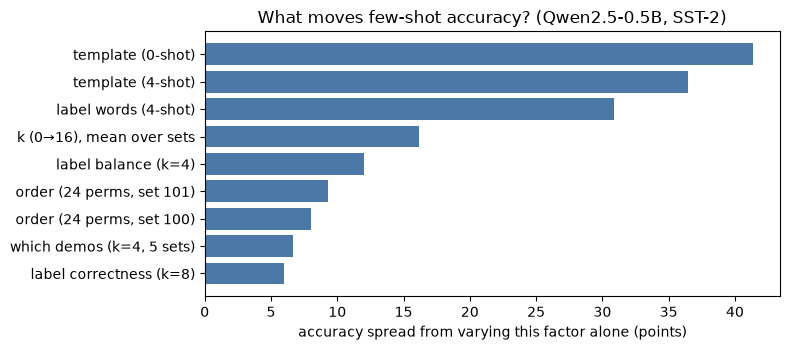

In [12]:
def spread(vals): return max(vals) - min(vals)
eff = {
    "k (0→16), mean over sets":  spread([ms(sel("count", k=k))[0] for k in ks]),
    "which demos (k=4, 5 sets)": spread([r["acc"] for r in sel("count", k=4)]),
    "order (24 perms, set 100)": spread([r["acc"] for r in sel("order", set=100)]),
    "order (24 perms, set 101)": spread([r["acc"] for r in sel("order", set=101)]),
    "template (0-shot)":         spread([sel("format", fmt=n, k=0)[0]["acc"] for n in names[:5]]),
    "template (4-shot)":         spread([ms(sel("format", fmt=n, k=4))[0] for n in names[:5]]),
    "label words (4-shot)":      spread([ms(sel("format", fmt=n, k=4))[0] for n in ["review"] + names[5:]]),
    "label correctness (k=8)":   spread([ms(sel("labels", variant=v))[0] for v in ["gold", "random", "flipped"]]),
    "label balance (k=4)":       spread([ms(sel("balance", n_pos=n))[0] for n in range(5)]),
}
eff = dict(sorted(eff.items(), key=lambda kv: kv[1]))
for k, v in reversed(eff.items()):
    print(f"{k:28} {v*100:5.1f} accuracy points")
plt.figure(figsize=(8, 3.6))
plt.barh(list(eff), [v * 100 for v in eff.values()], color="#4C78A8")
plt.xlabel("accuracy spread from varying this factor alone (points)"); plt.title("What moves few-shot accuracy? (Qwen2.5-0.5B, SST-2)")
plt.tight_layout(); plt.savefig(RESULTS / "summary_effects.png", dpi=130); plt.show()

## Sampling meets ICL

So far we compared label log-probs directly, which is equivalent to greedy decoding restricted to the labels. Real apps *sample* from the **full** vocabulary. So what is P(the sampled token is the correct label) under temperature, top-k and top-p, with and without demos?

0-shot: T=1 P(correct)=0.475  | T=1 top-k=40: 0.513  | T=1 top-p=0.9: 0.520  | T=0.1: 0.845


4-shot: T=1 P(correct)=0.771  | T=1 top-k=40: 0.777  | T=1 top-p=0.9: 0.817  | T=0.1: 0.893


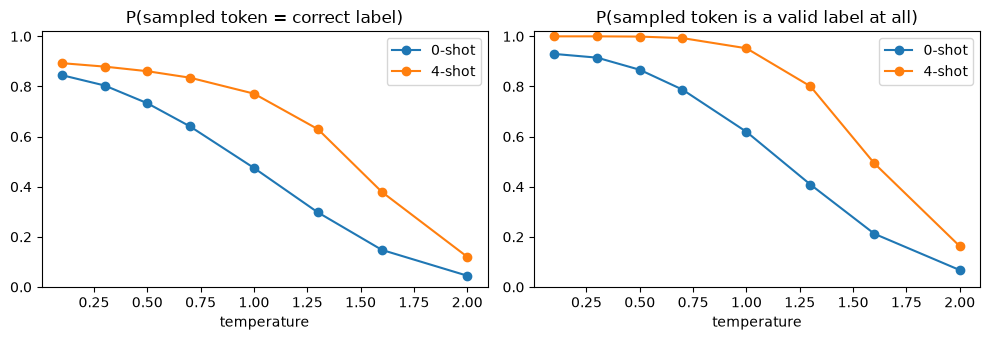

In [13]:
@torch.no_grad()
def full_logits(prefix, texts, fmt=BASE):
    out = []
    for t in texts:
        ids = tok(prefix + fmt.query(t), return_tensors="pt").input_ids
        out.append(model(ids).logits[0, -1].float())
    return torch.stack(out)

def p_correct(logits, gold_ids, label_ids, T=1.0, top_k=None, top_p=None):
    l = logits / T
    if top_k:
        l = l.masked_fill(l < l.topk(top_k, dim=-1).values[:, -1:], float("-inf"))
    if top_p:
        sl, si = l.sort(-1, descending=True); sp = sl.softmax(-1)
        drop = (sp.cumsum(-1) - sp) > top_p
        l = l.scatter(-1, si, sl.masked_fill(drop, float("-inf")))
    p = l.softmax(-1)
    return p.gather(1, gold_ids[:, None]).mean().item(), p[:, label_ids].sum(-1).mean().item()

SUB = TEST[:50]
lab = torch.tensor(label_token_ids(tok, BASE)); gold_ids = lab[[e.label for e in SUB]]
L = {"0-shot": full_logits("", [e.text for e in SUB]),
     "4-shot": full_logits(BASE.prefix(sample_demos(POOL, 4, 0)), [e.text for e in SUB])}
temps = [0.1, 0.3, 0.5, 0.7, 1.0, 1.3, 1.6, 2.0]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
for name, lg in L.items():
    pc = [p_correct(lg, gold_ids, lab, T) for T in temps]
    ax[0].plot(temps, [c for c, _ in pc], "o-", label=name); ax[1].plot(temps, [m for _, m in pc], "o-", label=name)
    print(f"{name}: T=1 P(correct)={pc[4][0]:.3f}  | T=1 top-k=40: {p_correct(lg, gold_ids, lab, 1, top_k=40)[0]:.3f}"
          f"  | T=1 top-p=0.9: {p_correct(lg, gold_ids, lab, 1, top_p=0.9)[0]:.3f}  | T=0.1: {pc[0][0]:.3f}")
ax[0].set_title("P(sampled token = correct label)"); ax[1].set_title("P(sampled token is a valid label at all)")
for a in ax: a.set_xlabel("temperature"); a.legend(); a.set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(RESULTS / "sampling_icl.png", dpi=130); plt.show()

## Context-window limits

### 1. The hard limit
GPT-2 has learned position embeddings for exactly 1,024 positions. Position 1,025 doesn't exist.

In [14]:
g2tok = AutoTokenizer.from_pretrained("gpt2"); g2 = AutoModelForCausalLM.from_pretrained("gpt2").eval()
for n in [1024, 1025]:
    try:
        with torch.no_grad(): g2(torch.zeros(1, n, dtype=torch.long))
        print(f"GPT-2 with {n} tokens: OK")
    except Exception as e:
        print(f"GPT-2 with {n} tokens: {type(e).__name__}: {str(e)[:90]}")
print(f"Qwen2.5-0.5B max_position_embeddings = {model.config.max_position_embeddings:,} (RoPE: no learned position table)")
del g2

GPT-2 with 1024 tokens: OK


GPT-2 with 1025 tokens: IndexError: index out of range in self
Qwen2.5-0.5B max_position_embeddings = 32,768 (RoPE: no learned position table)


### 2. Demos cost context
GPT-3 had a 2,048-token window, and the paper says the number of shots K was limited by how many examples fit in it.

In [15]:
per_demo = np.mean([r["prefix_tokens"] / r["k"] for r in sel("count") if r["k"] > 0])
print(f"~{per_demo:.0f} tokens per SST-2 demo  ->  ~{2048 // per_demo:.0f} demos fit in GPT-3's 2,048 window, "
      f"~{32768 // per_demo:,.0f} in Qwen2.5's 32k")

~29 tokens per SST-2 demo  ->  ~71 demos fit in GPT-3's 2,048 window, ~1,148 in Qwen2.5's 32k


### 3. Can the model actually *use* a long context? Passkey retrieval

We hide a 5-digit passkey at a chosen depth inside N tokens of filler text (movie reviews) and ask for it at the end. This is a simple "needle in a haystack" test, a cousin of *Lost in the Middle* (Liu et al., 2023).

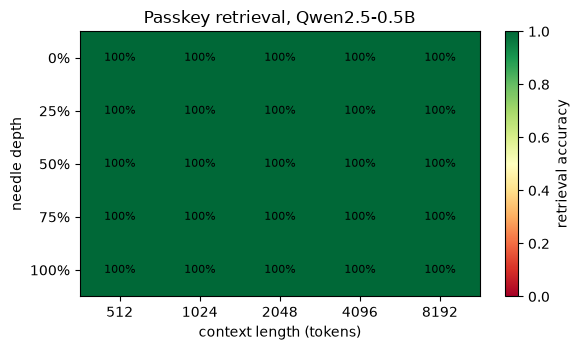

overall retrieval: 100%


In [16]:
PK = RESULTS / "passkey.json"
pk = json.loads(PK.read_text()) if PK.exists() else {}
filler = " ".join(e.text for e in random.Random(7).sample(train, 3000))
filler_ids = tok(filler).input_ids

@torch.no_grad()
def passkey_trial(n_tokens, depth, seed):
    rng = random.Random(seed * 1000 + n_tokens); key = str(rng.randint(10000, 99999))
    needle = f" The secret passkey is {key}. Remember it: {key} is the passkey. "
    ask = "\n\nWhat is the secret passkey? The secret passkey is"
    budget = n_tokens - len(tok(needle + ask).input_ids)
    start = rng.randint(0, len(filler_ids) - budget - 1)
    hay = filler_ids[start:start + budget]; cut = int(depth * len(hay))
    ids = hay[:cut] + tok(needle).input_ids + hay[cut:] + tok(ask).input_ids
    out = model.generate(torch.tensor([ids]), max_new_tokens=7, do_sample=False, pad_token_id=tok.eos_token_id)
    ans = tok.decode(out[0, len(ids):])
    return key in ans, ans

LENGTHS, DEPTHS = [512, 1024, 2048, 4096, 8192], [0.0, 0.25, 0.5, 0.75, 1.0]
for n in LENGTHS:
    for d in DEPTHS:
        for seed in range(2):
            kk = f"{n}|{d}|{seed}"
            if kk not in pk:
                t = time.time(); ok, ans = passkey_trial(n, d, seed); pk[kk] = ok
                PK.write_text(json.dumps(pk)); print(f"{kk:14} {'✓' if ok else '✗'} {ans!r} ({time.time()-t:.0f}s)", flush=True)

grid = np.array([[np.mean([pk[f"{n}|{d}|{s}"] for s in range(2)]) for n in LENGTHS] for d in DEPTHS])
plt.figure(figsize=(6, 3.6))
plt.imshow(grid, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
plt.xticks(range(len(LENGTHS)), LENGTHS); plt.yticks(range(len(DEPTHS)), [f"{d:.0%}" for d in DEPTHS])
plt.xlabel("context length (tokens)"); plt.ylabel("needle depth"); plt.colorbar(label="retrieval accuracy")
for i in range(len(DEPTHS)):
    for j in range(len(LENGTHS)): plt.text(j, i, f"{grid[i,j]:.0%}", ha="center", va="center", fontsize=8)
plt.title("Passkey retrieval, Qwen2.5-0.5B"); plt.tight_layout(); plt.savefig(RESULTS / "passkey.png", dpi=130); plt.show()
print("overall retrieval:", f"{np.mean(list(pk.values())):.0%}")

## Findings

Full write-up: `notes/week_2/README.md`.

1. **Format beats everything.** Template choice moved accuracy by 36–41 points and label words by 31. Order (8–9), which demos (7) and even label *correctness* (6) mattered far less.
2. **Demos teach format more than the task.** Label mass rises from 0.62 (0-shot) to 0.99 (16-shot). Random labels cost only ~1 point (replicates Min et al. 2022).
3. **Small models follow their prior.** With every demo label flipped, accuracy is still 84% (Wei et al. 2023: only large models follow flipped labels).
4. **One-shot (74%) was worse than zero-shot (87%).** More shots mostly reduce variance (std 0.10 → 0.01).
5. **Predictable biases:** recency (last demo positive → +10 pts positive predictions), majority label (+8 pts per extra positive demo), and the "question" template collapsing to "negative" 97% of the time (accuracy 49%, below chance).
6. **Calibration is a tool, not a fix:** it rescued the biased template (49% → up to 87%) but broke arbitrary labels (`foo/bar` 72% → 44%).
7. **Sampling:** 0-shot at T=1 gets the right label only 47.5% of the time vs 77% with 4 shots. For classification use T≈0.
8. **Context:** GPT-2 crashes at token 1,025. Passkey retrieval was 100% up to 8k tokens, but that's a copy task. An honest null result; harder tests (RULER, Lost in the Middle) are needed.